In [88]:
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_openai import ChatOpenAI

from dotenv import load_dotenv

load_dotenv()

True

In [89]:
llm = ChatOpenAI(model="gpt-4o-mini")
result = llm.invoke("I want to know the meaning of water")
print(result.content)

Water is a chemical substance consisting of two hydrogen atoms bonded to one oxygen atom, with the chemical formula H₂O. It is essential for all known forms of life and plays a critical role in various biological, chemical, and physical processes.

Here are a few key points about water:

1. **Physical Properties**: Water is a clear, colorless, odorless, and tasteless liquid at room temperature. It is unique in that it expands when it freezes, making ice less dense than liquid water.

2. **Biological Importance**: Water is vital for the survival of living organisms. It acts as a solvent, allows for biochemical reactions, helps in temperature regulation, and is important for transportation of nutrients and waste within organisms.

3. **Environmental Role**: Water is a major component of Earth's hydrosphere and is involved in the weather and climate systems through processes like evaporation, condensation, and precipitation.

4. **Cultural Significance**: Water holds various meanings and 

In [90]:
{"messages": "Water is a transparent, tasteless, odorless"}

{'messages': 'Water is a transparent, tasteless, odorless'}

In [91]:
from typing_extensions import TypedDict, Annotated
import operator


class MessagesState(TypedDict):
    messages: str

In [106]:
print(MessagesState({"messages": "hello"}))

{'messages': 'hello'}


In [ ]:
def chatbot(state: MessagesState):
    current_message = state['messages']
    state['messages'] = llm.invoke(current_message).content
    return state

In [93]:
graph_builder = StateGraph(state_schema=MessagesState)

## Build your nodes and edges

In [94]:
graph_builder.add_node("chatbot", chatbot)

In [95]:
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

## Compile the graph

In [96]:
graph = graph_builder.compile()

## Plot the graph

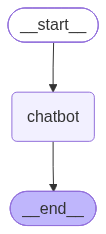

In [ ]:
from IPython.display import Image, display

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

## Run the entire graph

In [98]:
results = graph.invoke({"messages": "what is the chemical formula for water?"})

In [107]:
print(results)

{'messages': 'The chemical formula for water is H₂O. This means that each molecule of water is composed of two hydrogen atoms (H) and one oxygen atom (O).'}


In [103]:
print(results['messages'])

The chemical formula for water is H₂O. This means that each molecule of water is composed of two hydrogen atoms (H) and one oxygen atom (O).


## Build Social Media Bot

In [145]:
from pydantic import BaseModel, Field

class graph_schema(BaseModel):
    topic: str = Field(description="the topic of the graph")
    post: str = Field(description="the linkedin post")
    curated_post: str = Field(description="the curated linkedin post content")

In [151]:
def create_post(state: graph_schema):
    state = state.model_dump()
    topic = state['topic']
    state['post'] = llm.invoke(f"write a linkedin post about {topic}").content
    return state


def curated_post(state: graph_schema):
    state = state.model_dump()
    post = state['post']
    curated_post = llm.invoke(f"curate the following post with GenZ tone {post}").content
    state['curated_post'] = curated_post
    return state

In [152]:
graph_builder = StateGraph(state_schema=graph_schema)

graph_builder.add_node("create_post", create_post)
graph_builder.add_node("curate_post", curated_post)

graph_builder.add_edge(START, "create_post")
graph_builder.add_edge("create_post", "curate_post")
graph_builder.add_edge("curate_post", END)

In [153]:
graph = graph_builder.compile()

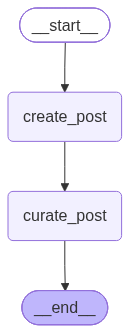

In [154]:
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [155]:
from pprint import pprint

results = graph.invoke(
    {"topic": "the importance of data privacy in the digital world", 
     "post": "", 
     "curated_post":""
     }
)

pprint(results)

{'curated_post': '🌐🔒 **Data Privacy: Let’s Talk About It!** 🔒🌐\n'
                 '\n'
                 'Alright fam, it’s time to have a real convo about data '
                 'privacy because, let’s be honest, it’s a BIG deal in our '
                 'tech-driven lives. Every time we click, like, or share, '
                 'we’re leaving a digital trail that can impact us in ways we '
                 'can’t always see. So, why should we give a 🦄 about data '
                 'privacy? Let’s break it down:\n'
                 '\n'
                 '1. **Building Trust**: Just like any solid relationship, '
                 'trust is everything! If companies keep it 100 about how they '
                 'use our data, we’re way more likely to stick around. '
                 'Transparency = loyalty, baby! 🙌\n'
                 '\n'
                 '2. **Legal Must-Haves**: With laws like GDPR and CCPA '
                 'shaking things up, it’s not just about being on the right

In [156]:
pprint(results['curated_post'])


('🌐🔒 **Data Privacy: Let’s Talk About It!** 🔒🌐\n'
 '\n'
 'Alright fam, it’s time to have a real convo about data privacy because, '
 'let’s be honest, it’s a BIG deal in our tech-driven lives. Every time we '
 'click, like, or share, we’re leaving a digital trail that can impact us in '
 'ways we can’t always see. So, why should we give a 🦄 about data privacy? '
 'Let’s break it down:\n'
 '\n'
 '1. **Building Trust**: Just like any solid relationship, trust is '
 'everything! If companies keep it 100 about how they use our data, we’re way '
 'more likely to stick around. Transparency = loyalty, baby! 🙌\n'
 '\n'
 '2. **Legal Must-Haves**: With laws like GDPR and CCPA shaking things up, '
 'it’s not just about being on the right side of the law—it’s about surviving '
 'the game. Ignore these rules and you might find yourself in some serious hot '
 'water (and by hot water, I mean fines and a wrecked reputation). 🚨💸\n'
 '\n'
 '3. **Stopping the Bad Guys**: Cyberattacks are getting sneakie